#### Importando a biblioteca Pandas e Matplotlib

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

#### Abrindo o arquivo CSV com o Pandas

In [3]:
dados = pd.read_csv('googleplaystore.csv')

## Etapa 1

#### Removendo linhas duplicadas

In [4]:
dados = dados.drop_duplicates()

## Etapa 2

In [ ]:
dados_agrupados = dados.groupby('App')['Installs'].sum().reset_index()

dados_agrupados.sort_values('Installs', ascending=False).head(5)

#### Percebi que a linha 10472 estava sem nada nas colunas "Category" e "Genres" então atribuí manualmente as informações corretas em suas respectivas colunas, adicionando "Uncategorized app" pois não havia categoria e "Tools" pois o nome do app indicou que fosse um app de ferramentas

In [6]:
indice = 10472
dados.loc[indice, "App"] = "Life Made WI-Fi Touchscreen Photo Frame"
dados.loc[indice, "Category"] = "Uncategorized app"
dados.loc[indice, "Rating"] = "1.9"
dados.loc[indice, "Reviews"] = "19"
dados.loc[indice, "Size"] = "3.0M"
dados.loc[indice, "Installs"] = "1,000+"
dados.loc[indice, "Type"] = "Free"
dados.loc[indice, "Price"] = "0"
dados.loc[indice, "Content Rating"] = "Everyone"
dados.loc[indice, "Genres"] = "Tools"
dados.loc[indice, "Last Updated"] = "February 11, 2018"
dados.loc[indice, "Current Ver"] = "1.0.19"
dados.loc[indice, "Android Ver"] = "4.0 and up"

C:\Users\isabe\AppData\Local\Temp\ipykernel_37696\2082382121.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.9' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  dados.loc[indice, "Rating"] = "1.9"


#### Removi o "+" e as vírgulas dos números, além disso, transformei a coluna de string para int, para dessa forma não abrir espaço a erros

In [7]:
dados['Installs'] = dados['Installs'].str.replace('[+,]', '', regex=True).astype(int)

#### Depois de tratar os dados fui descobrir os 5 apps com maior número de instalações

In [8]:
dados_agrupados = dados.groupby('App')['Installs'].sum().reset_index()

dados_agrupados.sort_values('Installs', ascending=False).head(5)


,App,Installs
8080,Subway Surfers,5000000000
4937,Google Photos,4000000000
5118,Hangouts,4000000000
4924,Google Drive,3000000000
5399,Instagram,3000000000


#### Fazendo o gráfico do resultado

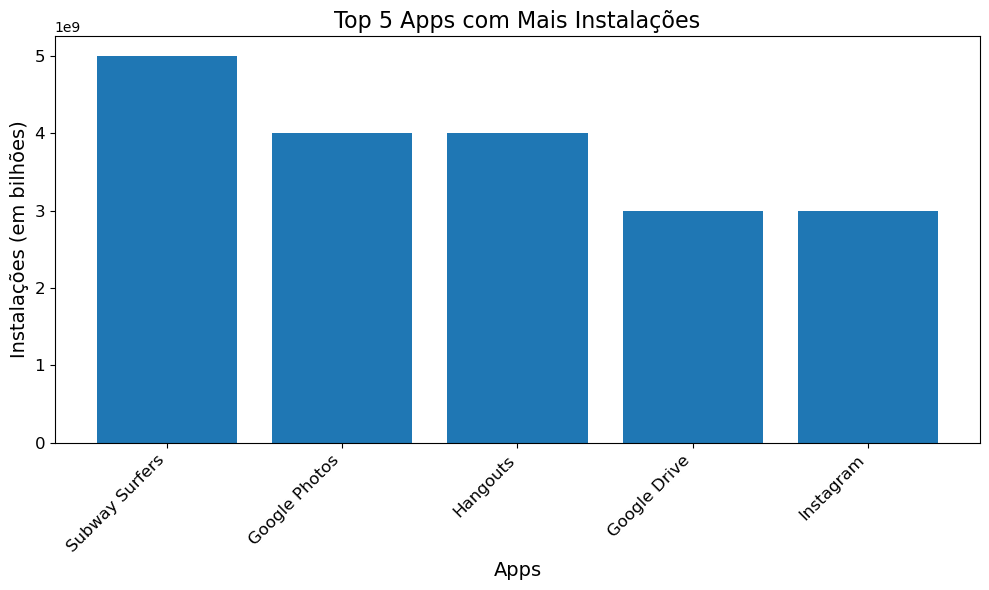

In [11]:
top5_installs = dados_agrupados[['App', 'Installs']].sort_values('Installs', ascending=False).head(5)
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(top5_installs['App'], top5_installs['Installs'])

plt.title("Top 5 Apps com Mais Instalações", fontsize=16)
plt.xlabel("Apps", fontsize=14)
plt.ylabel("Instalações (em bilhões)", fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

## Etapa 3

#### Descobrindo a frequência que cada categoria aparece no dataset

In [12]:
frequencias = dados['Category'].value_counts()

frequencias

Category
FAMILY                 1943
GAME                   1121
TOOLS                   843
BUSINESS                427
MEDICAL                 408
PRODUCTIVITY            407
PERSONALIZATION         388
LIFESTYLE               373
COMMUNICATION           366
FINANCE                 360
SPORTS                  351
PHOTOGRAPHY             322
HEALTH_AND_FITNESS      306
SOCIAL                  280
NEWS_AND_MAGAZINES      264
TRAVEL_AND_LOCAL        237
BOOKS_AND_REFERENCE     230
SHOPPING                224
DATING                  196
VIDEO_PLAYERS           175
MAPS_AND_NAVIGATION     137
EDUCATION               130
FOOD_AND_DRINK          124
ENTERTAINMENT           111
AUTO_AND_VEHICLES        85
LIBRARIES_AND_DEMO       85
WEATHER                  82
HOUSE_AND_HOME           80
ART_AND_DESIGN           65
EVENTS                   64
PARENTING                60
COMICS                   60
BEAUTY                   53
Uncategorized app         1
Name: count, dtype: int64

#### Como ficou um número muito grande de categorias, para representar no gráfico pizza ia ficar muito inelegível, então agrupei as categorias que possuem menos frequências e atribuí a uma nova categoria chamada "Outras"

In [14]:
limite = 0.035 * frequencias.sum() 
frequencias_relevantes = frequencias[frequencias >= limite]  
frequencia_outras = frequencias[frequencias < limite].sum()

frequencias_relevantes['Others'] = frequencia_outras 

#### Criando o gráfico

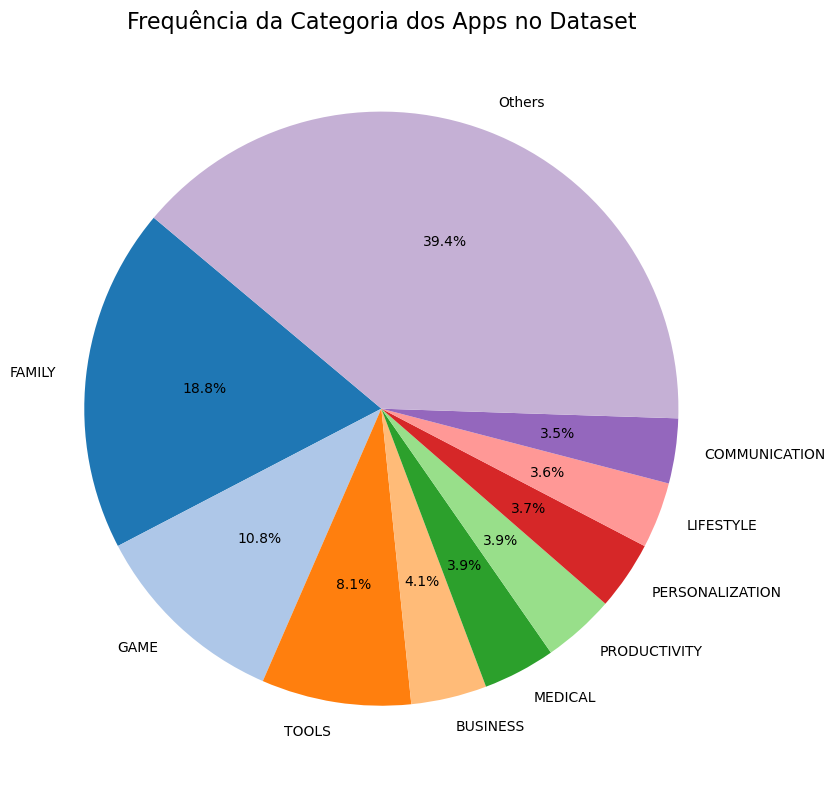

In [15]:
labels = frequencias_relevantes.index
sizes = frequencias_relevantes.values

plt.figure(figsize=(10, 8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=plt.cm.tab20.colors)
plt.title('Frequência da Categoria dos Apps no Dataset', fontsize=16)

plt.tight_layout()
plt.show()

## Etapa 4

#### App Mais Caro do Dataset

In [16]:
dados.sort_values('Price', ascending=False)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,10000,Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
7229,Pregnancy Tracker & Countdown to Baby Due Date,PARENTING,4.7,658087,62M,10000000,Free,0,Everyone,Parenting,"May 24, 2018",3.15.1,5.0 and up
7221,CE-SETRAM l’Appli,LIBRARIES_AND_DEMO,NaN,0,2.6M,100,Free,0,Everyone,Libraries & Demo,"December 5, 2017",1.1.8,4.0.3 and up
7222,CE KISIO,LIFESTYLE,NaN,1,24M,100,Free,0,Everyone,Lifestyle,"February 5, 2018",1.0.1,4.1 and up
7223,Terminal Emulator for Android,TOOLS,4.4,113951,551k,10000000,Free,0,Everyone,Tools,"April 15, 2015",1.0.70,1.6 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2300,Nursing Care Plan NANDA Tables,MEDICAL,3.0,4,3.4M,500,Paid,$0.99,Everyone,Medical,"May 9, 2017",1.0,2.3.3 and up
10682,Fruit Ninja Classic,GAME,4.3,85468,36M,1000000,Paid,$0.99,Everyone,Arcade,"June 8, 2018",2.4.1.485300,4.0.3 and up
2275,Blood Pressure Companion,MEDICAL,4.2,178,4.8M,1000,Paid,$0.99,Everyone,Medical,"July 22, 2018",4.1.5 (Steglitz),4.1 and up
6277,Bi-Tank Ads Free,GAME,NaN,0,Varies with device,1,Paid,$0.99,Everyone,Arcade,"July 31, 2017",1.1,4.1 and up


#### Percebi que na coluna "Price" tem um caractere "$" que dificulta a comparação de preços, sendo assim, tirei esse caratere e atribuí a toda coluna o tipo float

In [17]:
dados['Price'] = dados['Price'].str.replace('$', '').astype(float)


#### Descobrindo o App Mais Caro

In [18]:
dados[['App','Price']].sort_values('Price', ascending=False).head(1)

,App,Price
4367,I'm Rich - Trump Edition,400.0


## Etapa 5

#### Descobrindo quantos apps "Mature +17" existem no Dataset 

In [21]:
mature_17_plus = len(dados.loc[dados['Content Rating'] == 'Mature 17+'])
print(f'{mature_17_plus} apps são classificados como "Mature 17+"')

447 apps são classificados como "Mature 17+"


## Etapa 6

#### Top 10 Apps por número de Reviews

In [22]:
dados['Reviews'] = dados['Reviews'].astype(int)
dados[['App', 'Reviews']].sort_values('Reviews', ascending=False).head(10)

,App,Reviews
2544,Facebook,78158306
3943,Facebook,78128208
336,WhatsApp Messenger,69119316
3904,WhatsApp Messenger,69109672
2604,Instagram,66577446
2545,Instagram,66577313
3909,Instagram,66509917
382,Messenger – Text and Video Chat for Free,56646578
335,Messenger – Text and Video Chat for Free,56642847
1879,Clash of Clans,44893888


#### Como observei que tem apps se repetindo, eu tirei a média dos Reviews dos Apps que aparecem mais de uma vez e agrupei

In [23]:
dados_agrupados = dados.groupby('App')['Reviews'].mean().reset_index()

dados_ordenados = dados_agrupados.sort_values('Reviews', ascending=False)

dados_ordenados.head(10)

,App,Reviews
4328,Facebook,7.814326e+07
9042,WhatsApp Messenger,6.911449e+07
5399,Instagram,6.655489e+07
6166,Messenger – Text and Video Chat for Free,5.664471e+07
2564,Clash of Clans,4.488902e+07
2573,Clean Master- Space Cleaner & Antivirus,4.291653e+07
8080,Subway Surfers,2.772132e+07
9226,YouTube,2.563943e+07
7722,"Security Master - Antivirus, VPN, AppLock, Boo...",2.490100e+07
2561,Clash Royale,2.313257e+07


## Etapa 7

#### Top 5 apps pagos mais instalados

In [25]:
dados_agrupados = dados.loc[dados['Type'] == 'Paid'].groupby('App')['Installs'].sum().reset_index()

dados_agrupados.sort_values('Installs', ascending=False).head(5)


,App,Installs
457,Minecraft,20000000
366,Hitman Sniper,10000000
361,HD Widgets,2000000
627,Tasker,1000000
694,Where's My Water?,1000000


#### Quantidade de Apps com a classificação 5.0

In [27]:
dados['Rating'] = pd.to_numeric(dados['Rating'], errors='coerce')

quantidade_apps5 = (dados['Rating'] == 5.0).sum()
quantidade_apps5

print(f'{quantidade_apps5} apps possuem avaliação máxima (5.0)')

271 apps possuem avaliação máxima (5.0)


## Etapa 8

#### Gráfico dos 5 apps pagos mais instalados

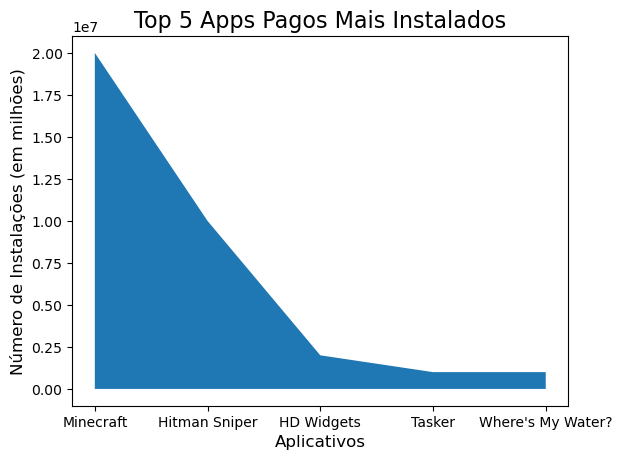

In [28]:
plt.fill_between(apps['App'], apps['Installs'])

plt.xlabel('Aplicativos', fontsize=12)
plt.ylabel('Número de Instalações (em milhões)', fontsize=12)
plt.title('Top 5 Apps Pagos Mais Instalados', fontsize=16)

plt.show()

#### Quantidade de Apps com as 3 Melhores Classificações

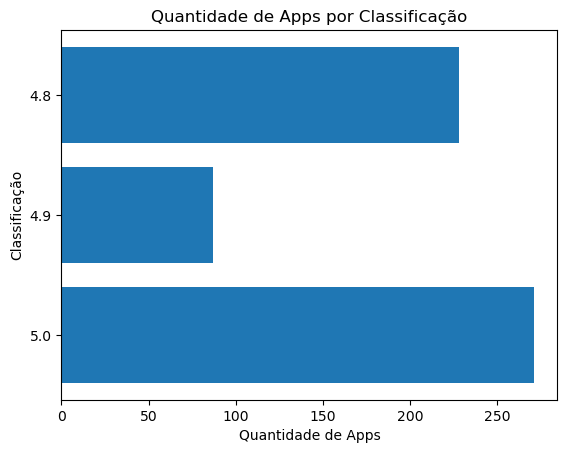

In [29]:
quantidade_apps5 = (dados['Rating'] == 5.0).sum()
quantidade_apps49 = (dados['Rating'] == 4.9).sum()
quantidade_apps48 = (dados['Rating'] == 4.8).sum()

classificacoes = ['5.0', '4.9', '4.8']
quantidades = [quantidade_apps5, quantidade_apps49, quantidade_apps48]

plt.barh(classificacoes, quantidades)

plt.xlabel('Quantidade de Apps')
plt.ylabel('Classificação')
plt.title('Quantidade de Apps por Classificação')

plt.show()

#### Destaquei a comparação do número de Apps com classificação 5.0 com a quantidade das 2 classificações antecessoras.